In [ ]:
import pandas as pd

df = pd.read_csv("/content/social_media_data.csv")

# Quick look
df.head()


,id,text,favorites,retweets,date,original_tweet,datetime,words,errors,errors_count,words_count,sentence_length,hour,month,year,Vader sentiment,user_name,finbert_sentiment,avg_sentiment,overall_sentiment
0,550441381253382144,thanks donald now run for president fulfill yo...,38.0,19.0,2015-01-01,"""""""@JaayZen: @realDonaldTrump Thanks Donald. N...",2015-01-01 00:00:26,"['thanks', 'donald', 'now', 'run', 'for', 'pre...",set(),0,16,90,0,1,2015,0.7003,Donald Trump,0.177490,0.438895,Positive
1,550441927964106753,first time in the trump international hotel an...,22.0,8.0,2015-01-01,"""""""@teamconquerca: First time in the""""Trump In...",2015-01-01 00:02:37,"['first', 'time', 'in', 'the', 'trump', 'inter...",{'itabsolutely'},1,17,115,0,1,2015,0.8807,Donald Trump,0.724102,0.802401,Positive
2,550442948375347200,he stands up for what he believes in regardles...,30.0,16.0,2015-01-01,"""""""@AngelaTN777: @gochico @realDonaldTrump: He...",2015-01-01 00:06:40,"['he', 'stands', 'up', 'for', 'what', 'he', 'b...",set(),0,14,69,0,1,2015,0.3612,Donald Trump,0.151212,0.256206,Positive
3,550443540111962113,he has all the ingredients to get elected and ...,15.0,13.0,2015-01-01,"""""""@JaayZen: @grandmiapens He has all the ingr...",2015-01-01 00:09:01,"['he', 'has', 'all', 'the', 'ingredients', 'to...",{'donlet'},1,20,102,0,1,2015,0.0000,Donald Trump,0.154325,0.077162,Positive
4,550443735054839808,one of the best thingsbought in 2014 ties,16.0,8.0,2015-01-01,"""""""@MarcAardvark: @realDonaldTrump @ronmeier12...",2015-01-01 00:09:47,"['one', 'of', 'the', 'best', 'thingsbought', '...",{'thingsbought'},1,8,41,0,1,2015,0.6369,Donald Trump,0.285142,0.461021,Positive


In [ ]:
# Remove rows where user_name is exactly "Mr. Tweet"
df = df[df["user_name"] != "Mr. Tweet"]

# Reset index (cleaner)
df = df.reset_index(drop=True)


In [ ]:
import pandas as pd

numeric_cols = [
    "Vader sentiment",
    "finbert_sentiment",
    "avg_sentiment"
]

# Ensure numeric
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

numeric_summary = (
    df
    .groupby("user_name")[numeric_cols]
    .agg(["mean", "std", "min", "max", "count"])
    .round(4)
)

numeric_summary

Vader sentiment                                finbert_sentiment  \
                        mean     std     min     max  count              mean   
user_name                                                                       
Donald Trump          0.1439  0.5028 -0.9837  0.9878  38141            0.0245   
Elon Musk             0.1148  0.3361 -0.9562  0.9432   5825            0.0206   
Joe Biden             0.1614  0.5036 -0.9771  0.9825   8648            0.0901   

                                            avg_sentiment                  \
                 std     min     max  count          mean     std     min   
user_name                                                                   
Donald Trump  0.3718 -0.9667  0.9373  38141        0.0842  0.3862 -0.9511   
Elon Musk     0.2648 -0.9680  0.9322   5825        0.0677  0.2560 -0.8746   
Joe Biden     0.3408 -0.9659  0.9357   8648        0.1258  0.3602 -0.9417   

                             
                 max  count  
user_name                    
Donald Trump  0.9389  38141  
Elon Musk     0.8816   5825  
Joe Biden     0.9229   8648

In [ ]:
sentiment_distribution = (
    df
    .groupby(["user_name", "overall_sentiment"])
    .size()
    .unstack(fill_value=0)
)

sentiment_distribution

overall_sentiment,Negative,Neutral,Positive
user_name,,,
Donald Trump,11552,5872,20717
Elon Musk,1210,2010,2605
Joe Biden,2207,1461,4980


In [ ]:
sentiment_percent = (
    df
    .groupby("user_name")["overall_sentiment"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .round(3)
)

sentiment_percent

overall_sentiment,Negative,Neutral,Positive
user_name,,,
Donald Trump,0.303,0.154,0.543
Elon Musk,0.208,0.345,0.447
Joe Biden,0.255,0.169,0.576


In [ ]:
import pandas as pd

hour_counts = (
    df.groupby(["user_name", "hour"])
      .size()
      .reset_index(name="count")
      .sort_values(["user_name", "hour"])
)

hour_counts.head()

,user_name,hour,count
0,Donald Trump,0,1766
1,Donald Trump,1,2113
2,Donald Trump,2,2291
3,Donald Trump,3,2050
4,Donald Trump,4,1626


In [ ]:
df["year_month"] = pd.to_datetime(
    df["year"].astype(int).astype(str) + "-" + df["month"].astype(int).astype(str).str.zfill(2) + "-01",
    errors="coerce"
)

monthly_counts = (
    df.dropna(subset=["year_month"])
      .groupby(["user_name", "year_month"])
      .size()
      .reset_index(name="count")
      .sort_values(["user_name", "year_month"])
)

monthly_counts.head()

,user_name,year_month,count
0,Donald Trump,2015-01-01,1119
1,Donald Trump,2015-02-01,468
2,Donald Trump,2015-03-01,404
3,Donald Trump,2015-04-01,798
4,Donald Trump,2015-05-01,707


In [ ]:
df["is_rth_hour_approx"] = df["hour"].between(10, 15)

rth_share = (
    df.groupby("user_name")["is_rth_hour_approx"]
      .mean()
      .mul(100)
      .round(2)
      .rename("pct_posts_in_rth_hours_approx")
      .reset_index()
)

rth_share

,user_name,pct_posts_in_rth_hours_approx
0,Donald Trump,35.51
1,Elon Musk,12.67
2,Joe Biden,13.15


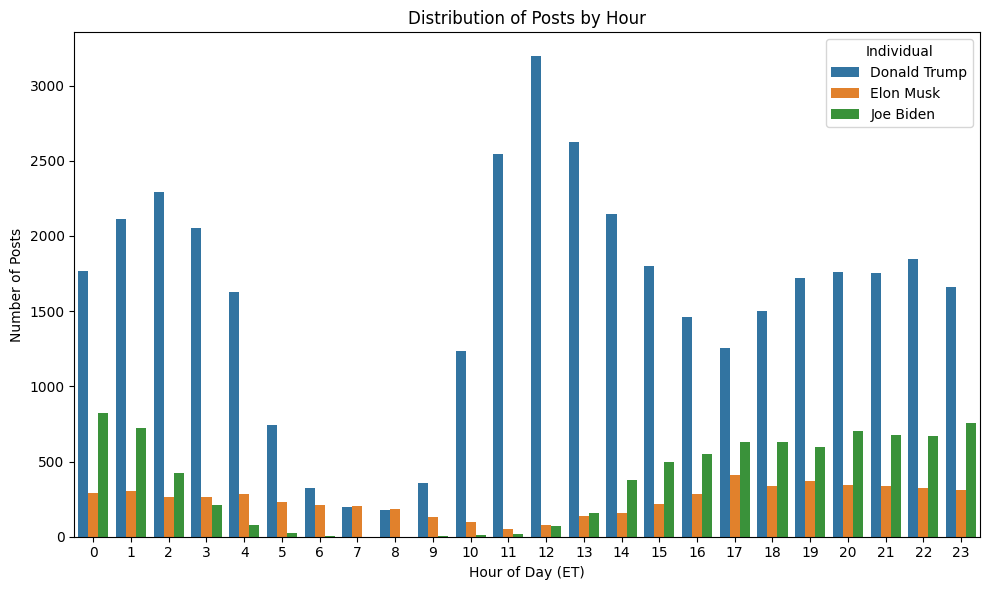

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count posts by hour and person
hour_counts = (
    df.groupby(["user_name", "hour"])
      .size()
      .reset_index(name="count")
)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=hour_counts,
    x="hour",
    y="count",
    hue="user_name"
)

plt.xlabel("Hour of Day (ET)")
plt.ylabel("Number of Posts")
plt.title("Distribution of Posts by Hour")
plt.legend(title="Individual")
plt.tight_layout()
plt.show()

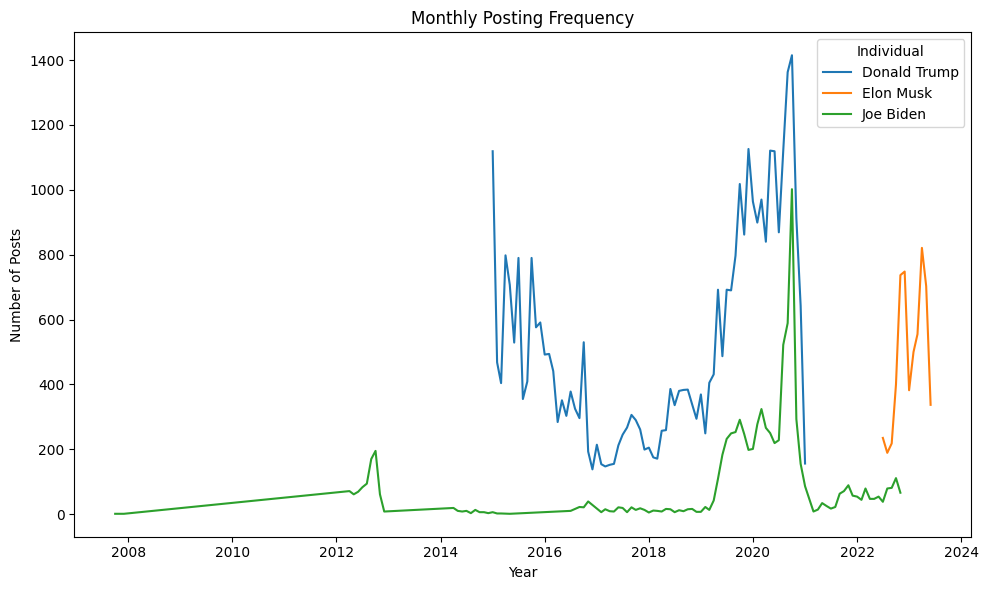

In [ ]:
# Monthly counts
monthly_counts = (
    df.groupby(["user_name", "year_month"])
      .size()
      .reset_index(name="count")
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=monthly_counts,
    x="year_month",
    y="count",
    hue="user_name"
)

plt.xlabel("Year")
plt.ylabel("Number of Posts")
plt.title("Monthly Posting Frequency")
plt.legend(title="Individual")
plt.tight_layout()
plt.show()

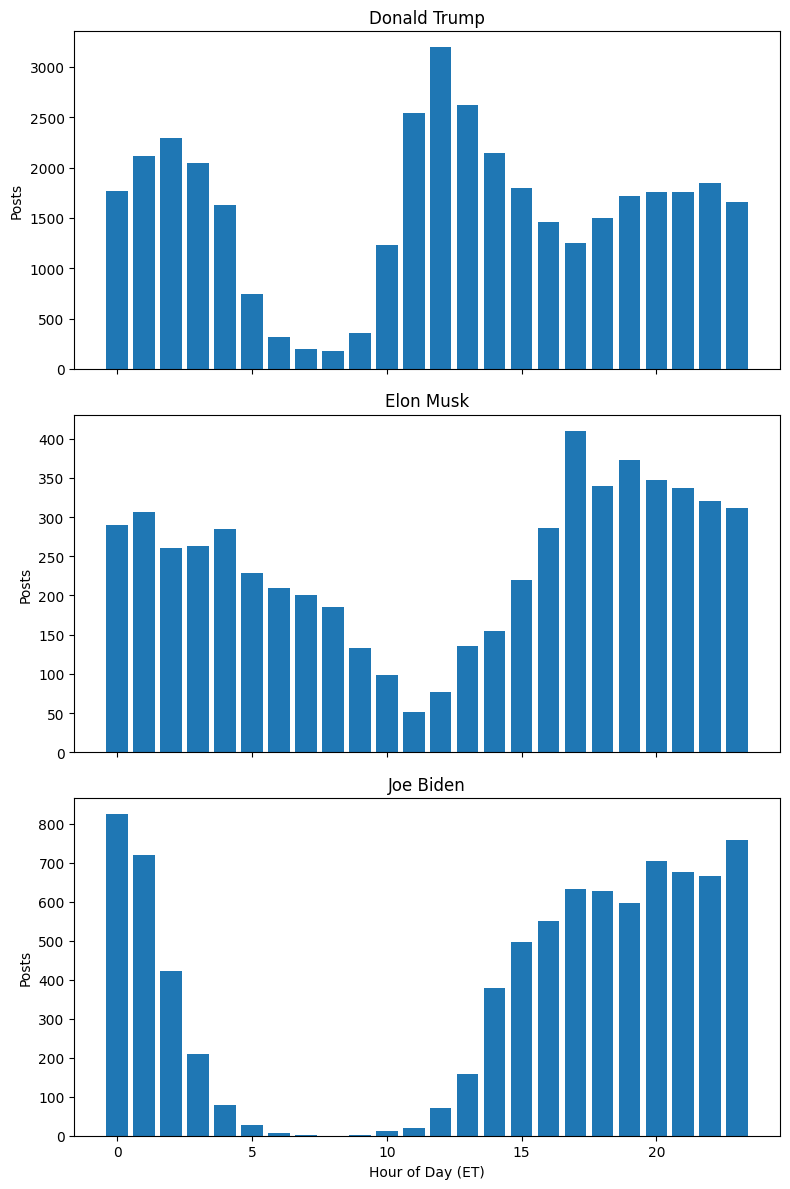

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8,12), sharex=True)

for ax, person in zip(axes, df["user_name"].unique()):
    subset = hour_counts[hour_counts["user_name"] == person]
    ax.bar(subset["hour"], subset["count"])
    ax.set_title(person)
    ax.set_ylabel("Posts")

axes[-1].set_xlabel("Hour of Day (ET)")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Recompute counts (safe)
hour_counts = (
    df.groupby(["user_name", "hour"])
      .size()
      .reset_index(name="count")
)

people = hour_counts["user_name"].unique()

fig, axes = plt.subplots(len(people), 1, figsize=(8, 10), sharex=True)

for ax, person in zip(axes, people):
    subset = hour_counts[hour_counts["user_name"] == person]
    ax.bar(subset["hour"], subset["count"], color="black")
    ax.set_title(person, fontsize=12)
    ax.set_ylabel("Posts")
    ax.set_xlim(0, 23)

axes[-1].set_xlabel("Hour of Day (ET)")

plt.tight_layout()
plt.savefig("hour_distribution.png", dpi=300)
plt.close()

In [ ]:
# Ensure year_month is datetime
df["year_month"] = pd.to_datetime(
    df["year"].astype(int).astype(str) + "-" +
    df["month"].astype(int).astype(str).str.zfill(2) + "-01",
    errors="coerce"
)

monthly_counts = (
    df.groupby(["user_name", "year_month"])
      .size()
      .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(9,6))

for person in monthly_counts["user_name"].unique():
    subset = monthly_counts[monthly_counts["user_name"] == person]
    ax.plot(subset["year_month"], subset["count"], label=person)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Posts")
ax.set_title("Monthly Posting Frequency")
ax.legend()

plt.tight_layout()
plt.savefig("monthly_frequency.png", dpi=300)
plt.close()

In [ ]:
eng_summary = (
    df.groupby("user_name")[["retweets", "favorites"]]
      .agg(["count", "mean", "median", "std",
            lambda s: s.quantile(0.90),
            lambda s: s.quantile(0.99),
            "max"])
)

# Rename the lambda columns nicely
eng_summary.columns = [
    "count", "mean", "median", "std", "p90", "p99", "max"
] * 2

eng_summary = eng_summary.round(2)
eng_summary

,count,mean,median,std,p90,p99,max,count,mean,median,std,p90,p99,max
user_name,,,,,,,,,,,,,,
Donald Trump,38141,12600.30,9447.0,14394.49,27302.0,67577.00,408866.0,38141,41875.71,9178.0,66252.92,109617.0,296079.20,1869706.0
Elon Musk,5825,5502.82,1085.0,14508.12,13970.6,59888.48,359672.0,5825,64056.55,18128.0,133370.98,162851.6,664969.52,2500167.0
Joe Biden,6064,6375.18,1776.0,14467.16,16723.1,59310.72,326070.0,6064,34935.77,8224.0,84908.43,88367.6,353961.63,1890946.0


In [ ]:
def p90(x): return x.quantile(0.90)
def p99(x): return x.quantile(0.99)

eng_summary = (
    df.groupby("user_name")
      .agg(
          retweets_count=("retweets", "count"),
          retweets_mean=("retweets", "mean"),
          retweets_median=("retweets", "median"),
          retweets_std=("retweets", "std"),
          retweets_p90=("retweets", p90),
          retweets_p99=("retweets", p99),
          retweets_max=("retweets", "max"),

          favorites_count=("favorites", "count"),
          favorites_mean=("favorites", "mean"),
          favorites_median=("favorites", "median"),
          favorites_std=("favorites", "std"),
          favorites_p90=("favorites", p90),
          favorites_p99=("favorites", p99),
          favorites_max=("favorites", "max"),
      )
      .round(2)
)

eng_summary

,retweets_count,retweets_mean,retweets_median,retweets_std,retweets_p90,retweets_p99,retweets_max,favorites_count,favorites_mean,favorites_median,favorites_std,favorites_p90,favorites_p99,favorites_max
user_name,,,,,,,,,,,,,,
Donald Trump,38141,12600.30,9447.0,14394.49,27302.0,67577.00,408866.0,38141,41875.71,9178.0,66252.92,109617.0,296079.20,1869706.0
Elon Musk,5825,5502.82,1085.0,14508.12,13970.6,59888.48,359672.0,5825,64056.55,18128.0,133370.98,162851.6,664969.52,2500167.0
Joe Biden,6064,6375.18,1776.0,14467.16,16723.1,59310.72,326070.0,6064,34935.77,8224.0,84908.43,88367.6,353961.63,1890946.0


In [ ]:
print(eng_summary.to_latex())

\begin{tabular}{lrrrrrrrrrrrrrr}
\toprule
 & retweets_count & retweets_mean & retweets_median & retweets_std & retweets_p90 & retweets_p99 & retweets_max & favorites_count & favorites_mean & favorites_median & favorites_std & favorites_p90 & favorites_p99 & favorites_max \\
user_name &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
Donald Trump & 38141 & 12600.300000 & 9447.000000 & 14394.490000 & 27302.000000 & 67577.000000 & 408866.000000 & 38141 & 41875.710000 & 9178.000000 & 66252.920000 & 109617.000000 & 296079.200000 & 1869706.000000 \\
Elon Musk & 5825 & 5502.820000 & 1085.000000 & 14508.120000 & 13970.600000 & 59888.480000 & 359672.000000 & 5825 & 64056.550000 & 18128.000000 & 133370.980000 & 162851.600000 & 664969.520000 & 2500167.000000 \\
Joe Biden & 6064 & 6375.180000 & 1776.000000 & 14467.160000 & 16723.100000 & 59310.720000 & 326070.000000 & 6064 & 34935.770000 & 8224.000000 & 84908.430000 & 88367.600000 & 353961.630000 & 1890946.000000 \\
\bottomrule
\end{tabular}



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure numeric
df["retweets"] = pd.to_numeric(df["retweets"], errors="coerce")
df["favorites"] = pd.to_numeric(df["favorites"], errors="coerce")

# Create log(1+x) versions (handles zeros)
df["log_retweets"] = np.log1p(df["retweets"])
df["log_favorites"] = np.log1p(df["favorites"])

people = ["Donald Trump", "Elon Musk", "Joe Biden"]  # keep consistent order
tmp = df[df["user_name"].isin(people)].copy()

# -------- Retweets boxplot --------
data_retweets = [tmp.loc[tmp["user_name"] == p, "log_retweets"].dropna() for p in people]

plt.figure(figsize=(7,5))
plt.boxplot(data_retweets, labels=people, showfliers=True)
plt.ylabel("log(1 + retweets)")
plt.title("Engagement Distribution by Individual (Retweets)")
plt.tight_layout()
plt.savefig("retweets_boxplot.png", dpi=300, bbox_inches="tight")
plt.close()

# -------- Favorites boxplot --------
data_favorites = [tmp.loc[tmp["user_name"] == p, "log_favorites"].dropna() for p in people]

plt.figure(figsize=(7,5))
plt.boxplot(data_favorites, labels=people, showfliers=True)
plt.ylabel("log(1 + favorites)")
plt.title("Engagement Distribution by Individual (Favorites)")
plt.tight_layout()
plt.savefig("favorites_boxplot.png", dpi=300, bbox_inches="tight")
plt.close()

/tmp/ipython-input-235/713111916.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_retweets, labels=people, showfliers=True)
/tmp/ipython-input-235/713111916.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_favorites, labels=people, showfliers=True)


In [ ]:
summary = df["user_name"].value_counts().reset_index()
summary.columns = ["Person", "Number of Posts"]

print(summary)


         Person  Number of Posts
0  Donald Trump            38141
1     Joe Biden             8648
2     Elon Musk             5825
3     Mr. Tweet               79


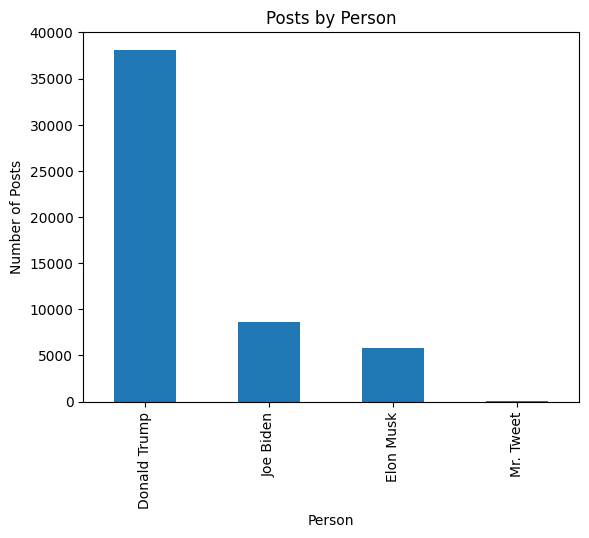

In [ ]:
import matplotlib.pyplot as plt

df["user_name"].value_counts().plot(kind="bar")
plt.title("Posts by Person")
plt.xlabel("Person")
plt.ylabel("Number of Posts")
plt.show()


In [ ]:
total_posts = len(df)
print("Total number of posts:", total_posts)


Total number of posts: 52614


In [ ]:
summary = df["user_name"].value_counts().reset_index()
summary.columns = ["Person", "Number of Posts"]

# Add percentage column
summary["Percentage"] = (summary["Number of Posts"] / total_posts) * 100

# Add total row
total_row = pd.DataFrame({
    "Person": ["TOTAL"],
    "Number of Posts": [total_posts],
    "Percentage": [100.0]
})

summary = pd.concat([summary, total_row], ignore_index=True)

summary


,Person,Number of Posts,Percentage
0,Donald Trump,38141,72.492112
1,Joe Biden,8648,16.436690
2,Elon Musk,5825,11.071198
3,TOTAL,52614,100.000000


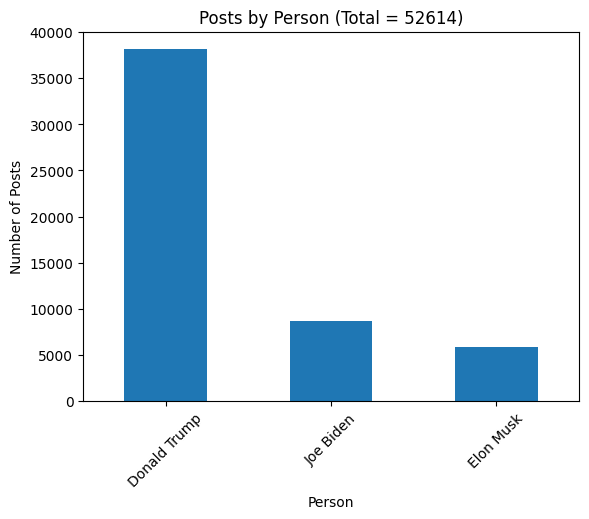

In [ ]:
import matplotlib.pyplot as plt

counts = df["user_name"].value_counts()

plt.figure()
counts.plot(kind="bar")
plt.title(f"Posts by Person (Total = {total_posts})")
plt.xlabel("Person")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.show()
